# MANTA - Preprocessing

This notebook prepares two tissue slices to be aligned by MANTA.

In [1]:
import anndata as ad
import manta

# I/O
from pathlib import Path

In [2]:
%load_ext autoreload
%autoreload 2

## File Inputs

The first step is to read in the `h5ad` files with `ad.read_h5ad`, which will read in the tissue slices in the AnnData format. The **source** is the tissue slice that will be aligned to the **target** slice.  

In [3]:
data_dir = Path("/staging/leuven/stg_00002/lcb/lcb_projects/SPF/mkovacic/data/dataset_MOUSE_BRAIN")

In [4]:
source = ad.read_h5ad(data_dir / "slice_75.h5ad")
target = ad.read_h5ad(data_dir / "slice_76.h5ad")

## Preprocessing

Before the slices can be aligned they need to be preprocessed. This entails the following steps:

1. Correcting batch-effects
2. Computing the PCA and NMF embeddings
3. Computing the set of genes present in both tissues (if tissue slices originate from different ST technologies)

**NOTE**: *All slices are required to store both their spatial information and gene names under the same key. If these differ between slices, make sure to manually correct this first.*

In [5]:
adatas = manta.preprocessing.preprocess(
    source=source,
    target=target,
    gene_key="gene_name",
    spatial_key="X_spatial_coords"
)

Preprocessing:   0%|          | 0/5 [00:00<?, ?it/s]

In [6]:
source = adatas[0]
target = adatas[1]

After preprocessing, we can visualize where the slices are located relative to each other using `manta.plotting.spatial`.

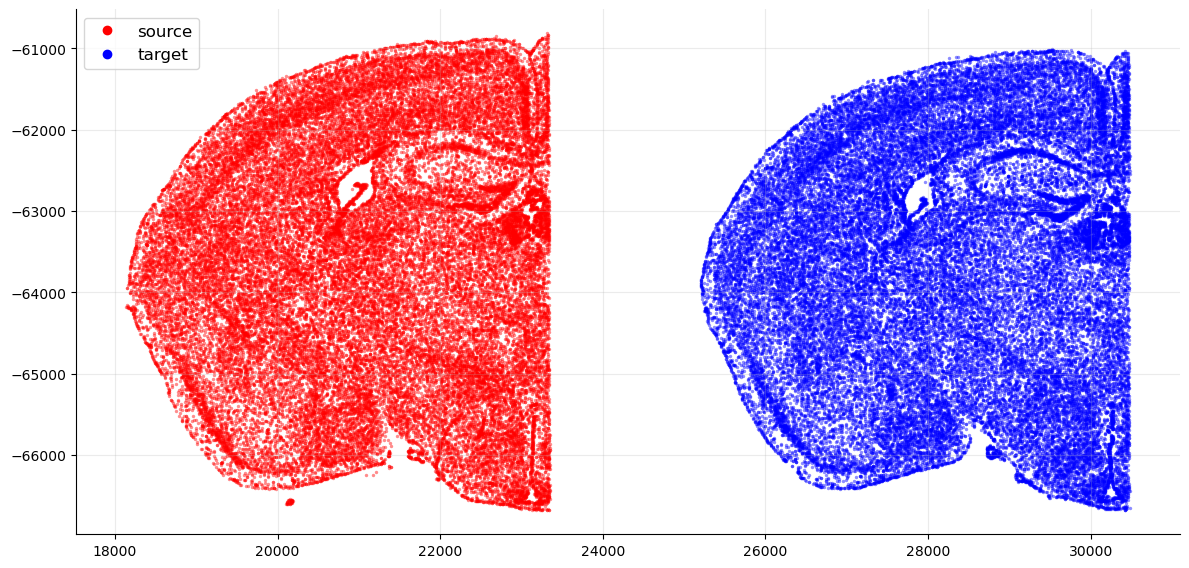

In [7]:
manta.plotting.spatial(
    adatas=adatas,
    labels=["source", "target"],
    colors=["red", "blue"],

    figsize=(12,12),
    alpha=0.45,
    marker_size=6,
    equal_aspect=True
)

## Sampling

**NOTE**: *This step is only required for non-rigid alignment.*

Since an alignment does not necessarily need all spatial observations, the tissue slices can be (sub)sampled. The `manta.sampling.sample` function can produce three different samplings:

* `importance`: samples observations based on the local density of observations (see later). Higher-density areas will be sampled more frequently. 
* `stratified`: samples observations by voxelizing the observations.
* `fps`: samples observations based on the furthest-point-sampling algorithm.

Depending on the type of tissues and the misalignment between them, different sampling routines may be preferred.

In [8]:
manta.sampling.sample(
    adatas=adatas,
    sampler="importance",
    fraction=0.25,
    bin_size=128,
    spatial_key="spatial_manta"
)

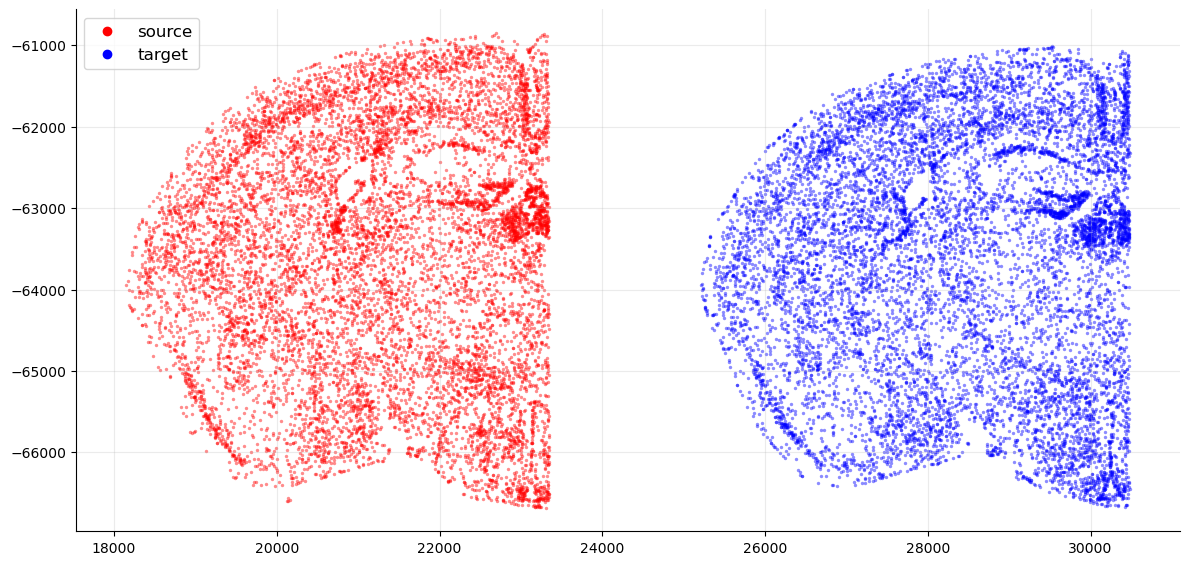

In [9]:
manta.plotting.sampling(
    adatas=adatas,
    labels=["source", "target"],
    colors=["red", "blue"],
    sampling_key="sampling",

    figsize=(12,12),
    alpha=0.45,
    marker_size=6,
    equal_aspect=True
)

The following cell shows what the density (and its derivative) of the source tissue looks like. As expected, regions with more observations exhibit a higher density.

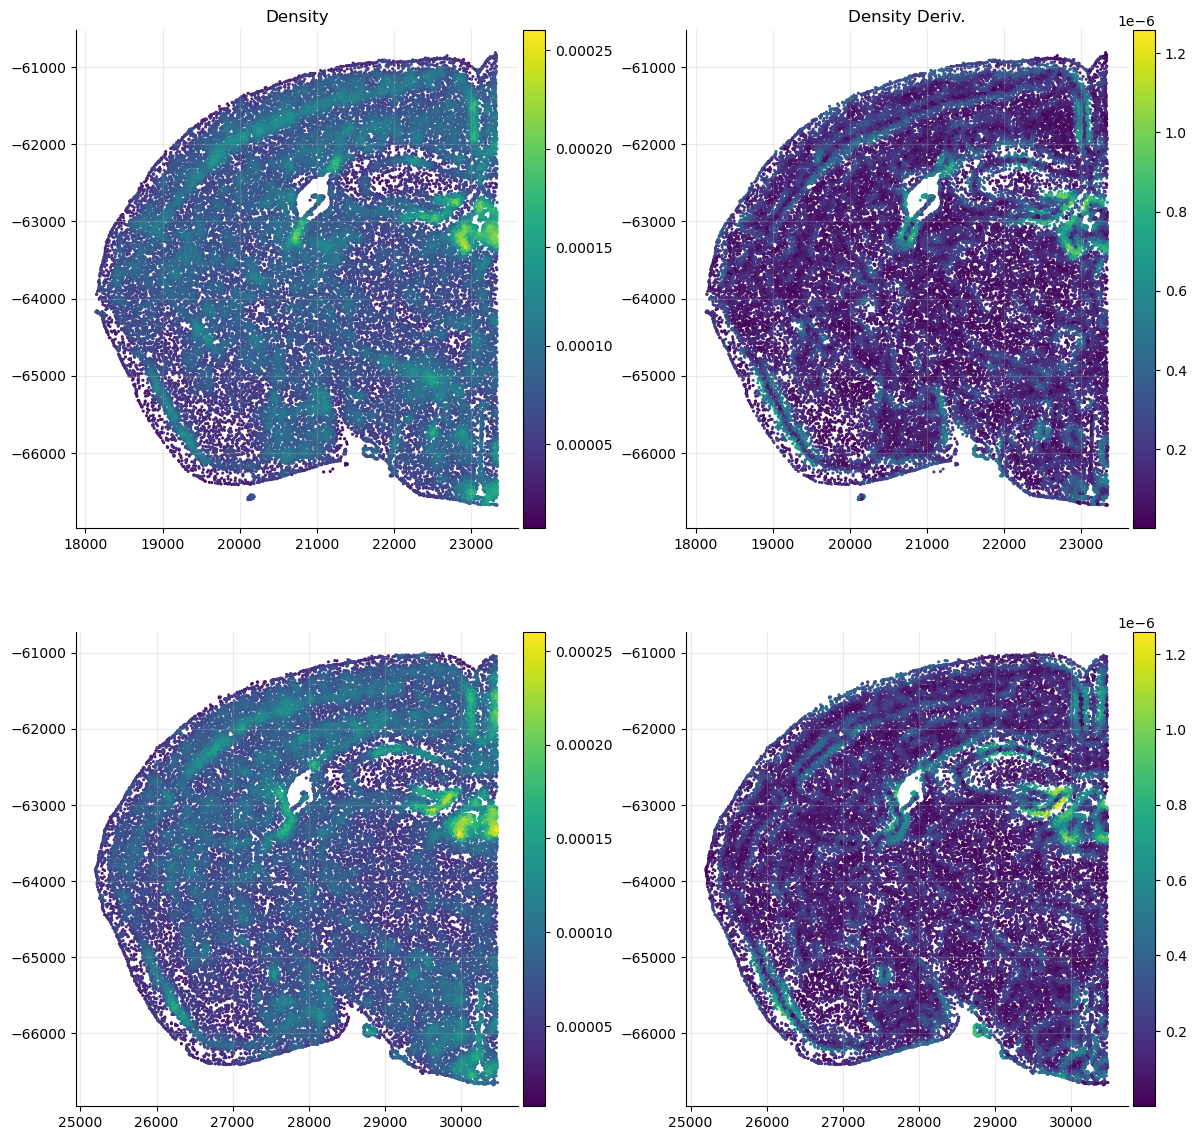

In [10]:
manta.plotting.density(
    adatas=adatas,
    labels=["source", "target"],
    density_key="rho_128",

    figsize=(12,12),
    marker_size=5,
    equal_aspect=True
)

## Next Steps

This concludes the required preprocessing steps in aligning two tissue slices in MANTA. The next notebook, `rigid_alignment.ipynb` will cover the steps required in order to perform a rigid alignment.